In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

REPO_URL = "https://github.com/yehonatan768/Facial_Recognition.git"   # change
DEST_DIR = Path("/content/Face_Recognition")            # choose folder name

if DEST_DIR.exists():
    print("Repo folder already exists:", DEST_DIR)
else:
    !git clone {REPO_URL} {DEST_DIR}

%cd /content/Face_Recognition
!git status

Cloning into '/content/Face_Recognition'...
remote: Enumerating objects: 685, done.
remote: Counting objects: 100% (255/255), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 685 (delta 171), reused 192 (delta 125), pack-reused 430 (from 1)
Receiving objects: 100% (685/685), 5.98 MiB | 19.27 MiB/s, done.
Resolving deltas: 100% (392/392), done.
/content/Face_Recognition
On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [3]:
!git checkout Sprint-3

Branch 'Sprint-3' set up to track remote branch 'Sprint-3' from 'origin'.
Switched to a new branch 'Sprint-3'


In [4]:
from pathlib import Path
import shutil

ZIP_ON_DRIVE = Path("/content/drive/MyDrive/Facial_Recognition/lfwa.zip")  # change if needed
ZIP_LOCAL = Path("/content/lfwa.zip")

shutil.copy2(ZIP_ON_DRIVE, ZIP_LOCAL)
print("Copied ZIP to local:", ZIP_LOCAL)

Copied ZIP to local: /content/lfwa.zip


In [5]:
import zipfile
from pathlib import Path
import shutil

ZIP_LOCAL = Path("/content/lfwa.zip")
IMAGES_DIR = Path("/content/Face_Recognition/images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

prefix = "lfw2/lfw2/"

with zipfile.ZipFile(ZIP_LOCAL) as z:
    for member in z.namelist():
        if member.startswith(prefix) and not member.endswith("/"):
            rel = Path(member).parts[len(Path(prefix).parts):]
            out = IMAGES_DIR.joinpath(*rel)

            out.parent.mkdir(parents=True, exist_ok=True)
            with z.open(member) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst)

print("Extracted locally into:", IMAGES_DIR)

Extracted locally into: /content/Face_Recognition/images


In [6]:
!ls

assets	images	notebooks  plots  README.md  requirements.txt  src


In [7]:
!git checkout Sprint-3
!git pull

Already on 'Sprint-3'
Your branch is up to date with 'origin/Sprint-3'.
Already up to date.


In [8]:
!git reset --hard
!git pull origin Sprint-3

HEAD is now at b62a251 played a bit with the config values
From https://github.com/yehonatan768/Facial_Recognition
 * branch            Sprint-3   -> FETCH_HEAD
Already up to date.


=== Filters (from config.yaml) ===
equalize.enabled = True | method=autocontrast | cutoff=1.0
edge.enabled     = True | mode=mix | alpha=0.1 | blur_radius=0.8
Loaded 2200 training pairs
Pipeline mode: advanced


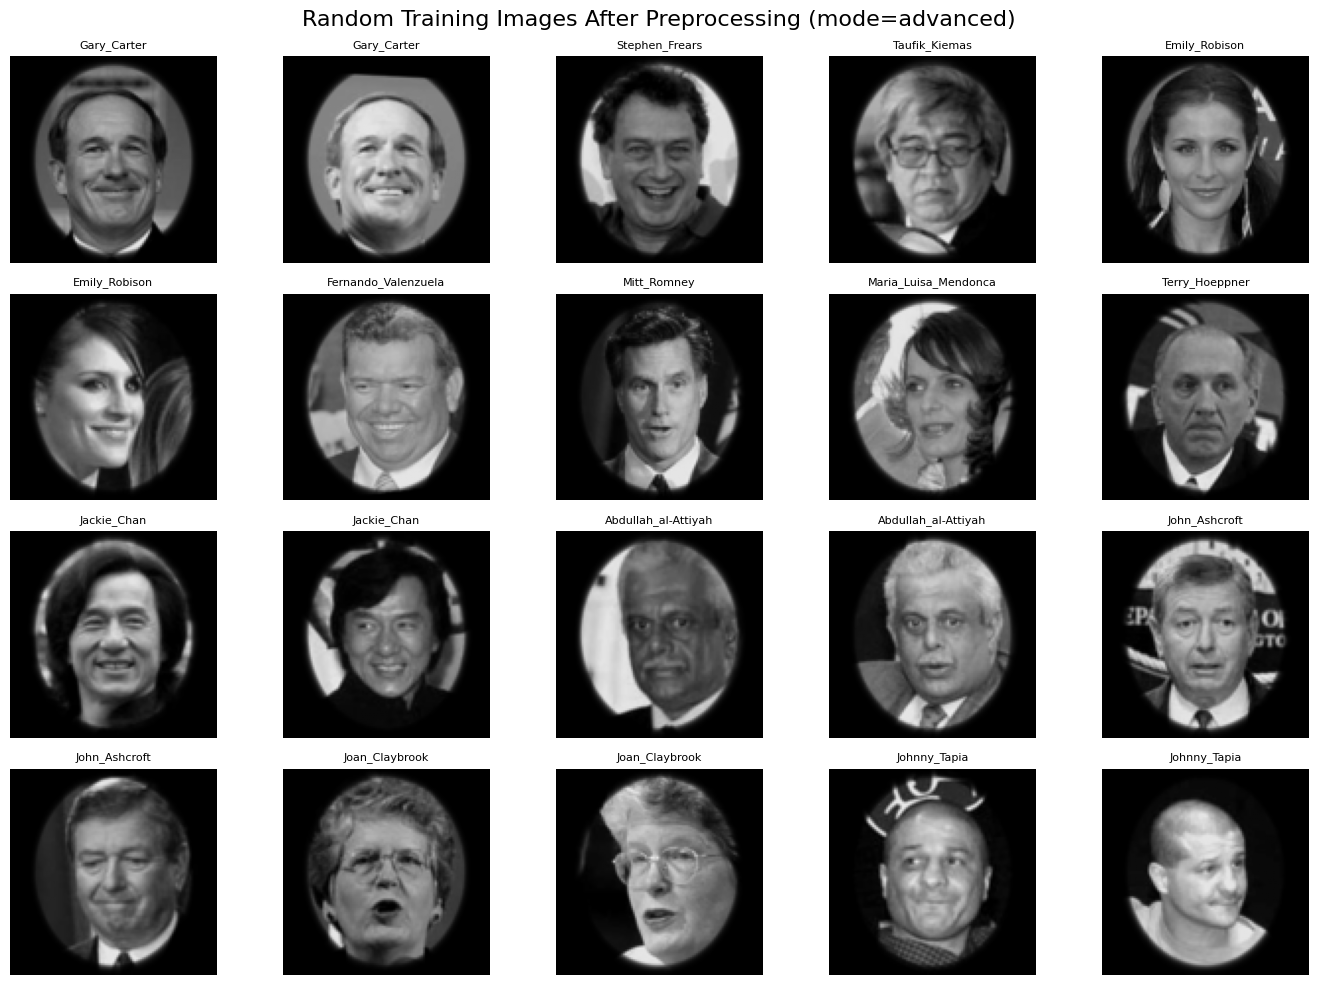

In [9]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch

from src.utils.read_config import read_model_config
from src.data.load_data import load_train_test_pairs
from src.preprocess.transforms import build_transform_from_config


def denormalize_tensor(x: torch.Tensor, mean: float, std: float) -> np.ndarray:
    """
    x: normalized tensor of shape (C,H,W) where C is 1 or 3
    returns:
      - if C==1: (H,W) float in [0,1]
      - if C==3: (H,W,3) float in [0,1]
    """
    x = x.detach().cpu()
    if x.dim() == 2:
        y = x * std + mean
        return np.clip(y.numpy(), 0.0, 1.0)

    if x.dim() != 3:
        raise ValueError(f"Expected (C,H,W) or (H,W), got {tuple(x.shape)}")

    c, h, w = x.shape
    y = x * std + mean
    y = y.numpy()

    if c == 1:
        return np.clip(y[0], 0.0, 1.0)
    if c == 3:
        return np.clip(np.transpose(y, (1, 2, 0)), 0.0, 1.0)

    # fallback: show first channel
    return np.clip(y[0], 0.0, 1.0)


# -------------------------
# Load config
# -------------------------
PROJECT_ROOT = Path.cwd().resolve()
CFG_PATH = PROJECT_ROOT / "src" / "config" / "config.yaml"
cfg = read_model_config(CFG_PATH, write_back=True)

PROJECT_ROOT = Path(cfg["paths"]["project_root"]).resolve()

# -------------------------
# Quick sanity print: filters used
# -------------------------
f = cfg.get("filters", {})
eq = f.get("equalize", {})
ed = f.get("edge", {})
print("=== Filters (from config.yaml) ===")
print(f"equalize.enabled = {eq.get('enabled', False)} | method={eq.get('method', 'autocontrast')} | cutoff={eq.get('autocontrast_cutoff', 0.0)}")
print(f"edge.enabled     = {ed.get('enabled', False)} | mode={ed.get('mode', 'mix')} | alpha={ed.get('alpha', 0.35)} | blur_radius={ed.get('blur_radius', 0.0)}")
print("==================================")

# -------------------------
# Resolve paths
# -------------------------
paths = cfg["paths"]
images_root = (PROJECT_ROOT / paths["images_root"]).resolve()
pairs_train = (PROJECT_ROOT / paths["pairs_train"]).resolve()
pairs_test = (PROJECT_ROOT / paths["pairs_test"]).resolve()

# -------------------------
# Load pairs
# -------------------------
loaded = load_train_test_pairs(
    train_pairs_path=pairs_train,
    test_pairs_path=pairs_test,
    images_root=images_root,
    ext=str(cfg["data"]["image_ext"]),
    strict_exists=bool(cfg["data"]["strict_exists"]),
)
train_pairs = loaded["train_pairs"]
print(f"Loaded {len(train_pairs)} training pairs")

# -------------------------
# Build transform (VAL-style: deterministic)
# -------------------------
mode = str(cfg["pipeline"]["mode"]).strip().lower()
print(f"Pipeline mode: {mode}")

transform = build_transform_from_config(cfg, train=False)

mean = float(cfg["transform"]["mean"])
std = float(cfg["transform"]["std"])

# -------------------------
# Sample 20 random images (10 pairs)
# -------------------------
sample_pairs = random.sample(train_pairs, 10)
image_paths = []
for p1, p2, *_ in sample_pairs:
    image_paths.extend([p1, p2])

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):
    img_path = Path(img_path)

    # Always start as RGB PIL; pipeline will handle grayscale/masking/filters.
    img = Image.open(img_path).convert("RGB")
    x = transform(img)  # torch.Tensor (C,H,W)

    x_vis = denormalize_tensor(x, mean=mean, std=std)

    if x_vis.ndim == 2:
        ax.imshow(x_vis, cmap="gray", vmin=0.0, vmax=1.0)
    else:
        ax.imshow(x_vis, vmin=0.0, vmax=1.0)

    ax.set_title(img_path.parent.name, fontsize=8)
    ax.axis("off")

plt.suptitle(
    f"Random Training Images After Preprocessing (mode={mode})",
    fontsize=16,
)
plt.tight_layout()
plt.show()


In [10]:
!git pull origin Sprint-3

From https://github.com/yehonatan768/Facial_Recognition
 * branch            Sprint-3   -> FETCH_HEAD
Already up to date.


In [11]:
!python -m src.run.train

2025-12-29 21:42:34 | INFO | train | Device: cuda
2025-12-29 21:42:34 | INFO | train | Loaded train pairs: 2200
2025-12-29 21:42:34 | INFO | train | Loaded test pairs:  1000
2025-12-29 21:42:34 | INFO | train | Train positives: 1100 | negatives: 1100
2025-12-29 21:42:34 | INFO | train | Test positives:  500 | negatives: 500
2025-12-29 21:42:44 | INFO | train | [Split] train pairs: n=1540 pos_frac=0.503 | val pairs: n=660 pos_frac=0.494 | target_val_pairs=660 target_pos_frac=0.50
2025-12-29 21:42:44 | INFO | train | [Split] train_ids=1693 | val_ids=439 | components=1032
2025-12-29 21:42:45 | INFO | train | Train=1540 | Val=660 | Test=1000 | epochs=200 batch_size=64
2025-12-29 21:43:18 | INFO | train | Epoch 001/200 | train_loss=0.693196 val_loss=0.692681 | train_acc=0.4903 val_acc=0.4742 | lr=0.00200000 momentum=0.600
2025-12-29 21:43:52 | INFO | train | Epoch 002/200 | train_loss=0.692118 val_loss=0.691282 | train_acc=0.4955 val_acc=0.4879 | lr=0.00198000 momentum=0.605
2025-12-29 21:4

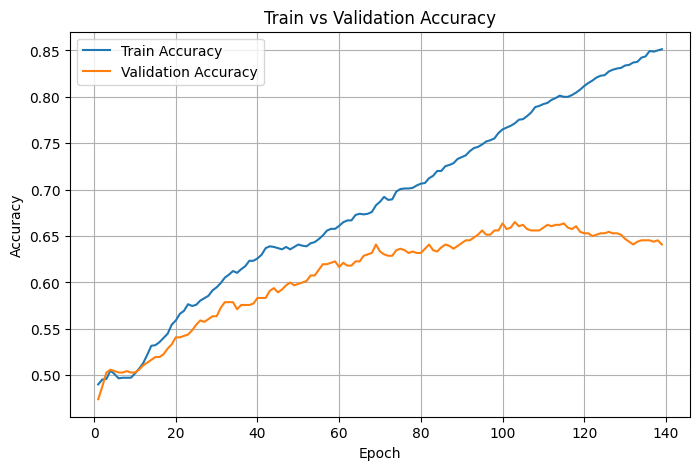

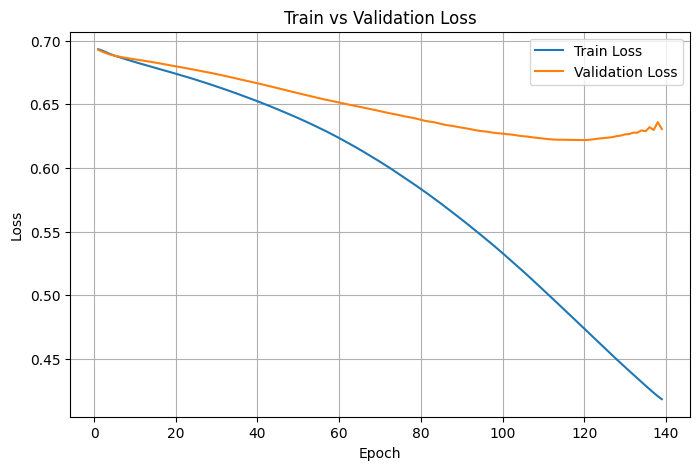

In [12]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Path to saved metrics
metrics_path = Path("outputs/metrics.json")  # adjust if needed

# Load metrics
with open(metrics_path, "r") as f:
    metrics = json.load(f)

epochs = metrics["epoch"]
train_loss = metrics["train_loss"]
val_loss = metrics["val_loss"]
train_acc = metrics["train_acc"]
val_acc = metrics["val_acc"]

# -------------------------
# Plot Accuracy
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Plot Loss
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
from src.models.siamese import PaperSiameseModel as model

model = model()
print('number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

number of parameters: 38951744
